<a href="https://colab.research.google.com/github/rsouparnika/ML-2/blob/main/Program_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

==================== RULE LEARNING : RIPPER / CN2 + FOIL =====================

DATASET
+-----------+---------------+------------+--------+--------+
| Outlook   | Temperature   | Humidity   | Wind   | Play   |
+===========+===============+============+========+========+
| Sunny     | Hot           | High       | Weak   | No     |
+-----------+---------------+------------+--------+--------+
| Sunny     | Hot           | High       | Strong | No     |
+-----------+---------------+------------+--------+--------+
| Overcast  | Hot           | High       | Weak   | Yes    |
+-----------+---------------+------------+--------+--------+
| Rain      | Mild          | High       | Weak   | Yes    |
+-----------+---------------+------------+--------+--------+
| Rain      | Cool          | Normal     | Weak   | Yes    |
+-----------+---------------+------------+--------+--------+
| Rain      | Cool          | Normal     | Strong | No     |
+-----------+---------------+------------+--------+-------

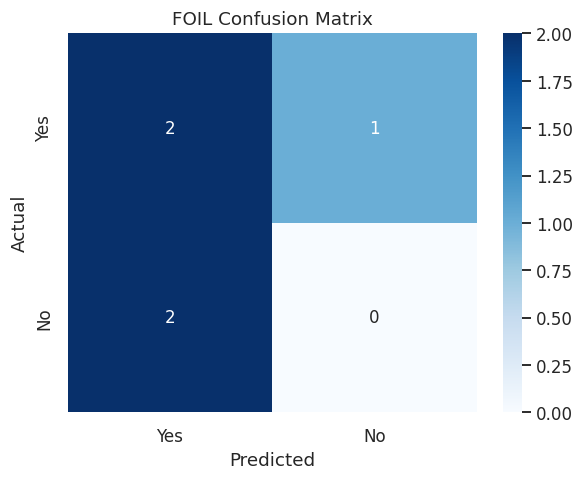

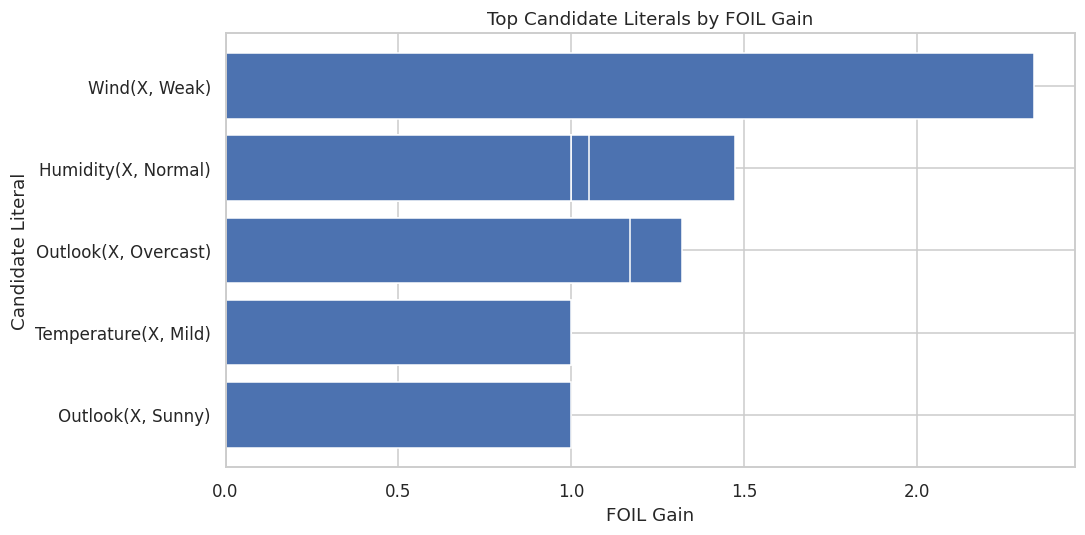


=============================== RULE COVERAGE ================================
+--------+------------------------------------------+-----------------+------------+------------+
| Rule   | Learned Rule                             | Total Covered   | Positive   | Negative   |
+========+==========================================+=================+============+============+
| R1     | Wind = Weak                              | 4               | 4          | 0          |
+--------+------------------------------------------+-----------------+------------+------------+
| R2     | Humidity = Normal AND Outlook = Overcast | 1               | 1          | 0          |
+--------+------------------------------------------+-----------------+------------+------------+
| R3     | Outlook = Sunny AND Temperature = Mild   | 1               | 1          | 0          |
+--------+------------------------------------------+-----------------+------------+------------+
| ALL    | Union of learned rules     

In [1]:
# ============================================================================
#  RULE LEARNING USING RIPPER / CN2 AND FOIL
#  Classification Rules + First Order Inductive Learning
#  Google Colab Ready
# ============================================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn tabulate

import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


# ============================================================================
# SECTION 1 : CREATE / READ THE DATASET
# ============================================================================

# Play Tennis dataset
data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain",
        "Rain", "Overcast", "Sunny", "Sunny", "Rain",
        "Sunny", "Overcast", "Overcast", "Rain"
    ],

    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool",
        "Cool", "Cool", "Mild", "Cool", "Mild",
        "Mild", "Mild", "Hot", "Mild"
    ],

    "Humidity": [
        "High", "High", "High", "High", "Normal",
        "Normal", "Normal", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "High"
    ],

    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Strong"
    ],

    "Play": [
        "No", "No", "Yes", "Yes", "Yes",
        "No", "Yes", "No", "Yes", "Yes",
        "Yes", "Yes", "Yes", "No"
    ]
}

df = pd.DataFrame(data)

print("=" * 78)
print(" RULE LEARNING : RIPPER / CN2 + FOIL ".center(78, "="))
print("=" * 78)

print("\nDATASET")
print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

print("\nDataset shape :", df.shape)

print("\nClass distribution:")
print(df["Play"].value_counts())


# ============================================================================
# SECTION 2 : TRAIN / TEST SPLIT
# ============================================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["Play"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "=" * 78)
print(" TRAIN / TEST SPLIT ".center(78, "="))
print("=" * 78)

print("\nTraining samples :", len(train_df))
print("Testing samples  :", len(test_df))

print("\nTRAINING DATA")
print(tabulate(train_df, headers="keys", tablefmt="grid", showindex=False))

print("\nTEST DATA")
print(tabulate(test_df, headers="keys", tablefmt="grid", showindex=False))


# ============================================================================
# SECTION 3 : RIPPER-STYLE RULE LEARNING
# ============================================================================

FEATURES = ["Outlook", "Temperature", "Humidity", "Wind"]
TARGET = "Play"

POSITIVE_CLASS = "Yes"
NEGATIVE_CLASS = "No"


def rule_covers(row, conditions):
    """
    Check whether a row satisfies all conditions in a rule.
    """

    for feature, value in conditions.items():
        if row[feature] != value:
            return False

    return True


def rule_coverage(dataframe, conditions, target_value=None):
    """
    Return rows covered by a rule.
    """

    mask = pd.Series(True, index=dataframe.index)

    for feature, value in conditions.items():
        mask &= dataframe[feature] == value

    if target_value is not None:
        mask &= dataframe[TARGET] == target_value

    return dataframe[mask]


def rule_quality(dataframe, conditions, target_value=POSITIVE_CLASS):
    """
    Calculate precision of a rule.
    """

    covered = rule_coverage(dataframe, conditions)

    if len(covered) == 0:
        return 0

    positives = len(
        covered[covered[TARGET] == target_value]
    )

    return positives / len(covered)


def generate_candidates(dataframe, conditions):
    """
    Generate candidate conditions not already present.
    """

    candidates = []

    for feature in FEATURES:

        if feature in conditions:
            continue

        for value in sorted(dataframe[feature].unique()):

            new_conditions = conditions.copy()
            new_conditions[feature] = value

            candidates.append(new_conditions)

    return candidates


def condition_to_string(conditions):

    if not conditions:
        return "TRUE"

    parts = []

    for feature, value in conditions.items():
        parts.append(f"{feature} = {value}")

    return " AND ".join(parts)


def learn_ripper_style(dataframe):
    """
    Simplified RIPPER-style sequential covering algorithm.

    It repeatedly finds a rule that covers positive examples
    while minimizing negative examples.
    """

    remaining_positive = dataframe[
        dataframe[TARGET] == POSITIVE_CLASS
    ].copy()

    rules = []

    while len(remaining_positive) > 0:

        best_rule = {}
        best_score = -1

        candidates = [{}]

        # Greedy specialization
        while True:

            candidate_scores = []

            for conditions in candidates:

                covered = rule_coverage(
                    dataframe,
                    conditions
                )

                if len(covered) == 0:
                    continue

                positives = len(
                    covered[
                        covered[TARGET] == POSITIVE_CLASS
                    ]
                )

                negatives = len(
                    covered[
                        covered[TARGET] == NEGATIVE_CLASS
                    ]
                )

                if positives == 0:
                    continue

                precision = positives / (
                    positives + negatives
                )

                candidate_scores.append(
                    (
                        precision,
                        positives,
                        -negatives,
                        conditions
                    )
                )

            if not candidate_scores:
                break

            candidate_scores.sort(
                key=lambda x: (
                    x[0],
                    x[1],
                    x[2]
                ),
                reverse=True
            )

            current = candidate_scores[0]

            best_rule = current[3]
            best_score = current[0]

            covered = rule_coverage(
                dataframe,
                best_rule
            )

            negatives = len(
                covered[
                    covered[TARGET] == NEGATIVE_CLASS
                ]
            )

            # Stop if rule is pure
            if negatives == 0:
                break

            # Generate more specific rules
            candidates = generate_candidates(
                dataframe,
                best_rule
            )

            # If no more specialization possible
            if not candidates:
                break

        if not best_rule:
            break

        rules.append(best_rule)

        # Remove positive examples already covered
        covered_positive = rule_coverage(
            remaining_positive,
            best_rule
        )

        if len(covered_positive) == 0:
            break

        remaining_positive = remaining_positive[
            ~remaining_positive.index.isin(
                covered_positive.index
            )
        ]

    return rules


RIPPER_RULES = learn_ripper_style(train_df)


print("\n" + "=" * 78)
print(" RIPPER-STYLE LEARNED RULES ".center(78, "="))
print("=" * 78)

for i, rule in enumerate(RIPPER_RULES, 1):

    print(
        f"R{i}: IF {condition_to_string(rule)} "
        f"THEN Play = {POSITIVE_CLASS}"
    )


# ============================================================================
# SECTION 4 : RIPPER PREDICTION
# ============================================================================

def ripper_predict(row, rules):

    for rule in rules:

        if rule_covers(row, rule):
            return POSITIVE_CLASS

    return NEGATIVE_CLASS


test_predictions_ripper = []

for _, row in test_df.iterrows():

    prediction = ripper_predict(
        row,
        RIPPER_RULES
    )

    test_predictions_ripper.append(prediction)


test_ripper = test_df.copy()

test_ripper["Predicted"] = test_predictions_ripper

ripper_accuracy = accuracy_score(
    test_ripper[TARGET],
    test_ripper["Predicted"]
)

print("\nRIPPER PREDICTIONS")
print(
    tabulate(
        test_ripper,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

print(
    "\nRIPPER Accuracy : %.2f%%"
    % (ripper_accuracy * 100)
)


# ============================================================================
# SECTION 5 : CN2-STYLE RULE LEARNING
# ============================================================================

def entropy(values):

    counts = Counter(values)

    total = len(values)

    if total == 0:
        return 0

    result = 0

    for count in counts.values():

        p = count / total

        result -= p * math.log2(p)

    return result


def information_gain(parent, child):

    if len(child) == 0:
        return 0

    return (
        entropy(parent[TARGET])
        -
        entropy(child[TARGET])
    )


def generate_cn2_candidates(dataframe, current_conditions):

    candidates = []

    for feature in FEATURES:

        if feature in current_conditions:
            continue

        for value in sorted(
            dataframe[feature].unique()
        ):

            conditions = current_conditions.copy()

            conditions[feature] = value

            covered = rule_coverage(
                dataframe,
                conditions
            )

            if len(covered) > 0:

                gain = information_gain(
                    dataframe,
                    covered
                )

                candidates.append(
                    (
                        gain,
                        conditions,
                        covered
                    )
                )

    return candidates


def learn_cn2(dataframe):

    remaining = dataframe.copy()

    rules = []

    while len(remaining) > 0:

        current = {}

        while True:

            candidates = generate_cn2_candidates(
                remaining,
                current
            )

            if not candidates:
                break

            candidates.sort(
                key=lambda x: x[0],
                reverse=True
            )

            gain, best_conditions, covered = (
                candidates[0]
            )

            current = best_conditions

            # Stop when all covered examples
            # belong to the same class
            if len(
                covered[TARGET].unique()
            ) == 1:
                break

        if not current:
            break

        covered = rule_coverage(
            remaining,
            current
        )

        if len(covered) == 0:
            break

        majority_class = (
            covered[TARGET]
            .value_counts()
            .idxmax()
        )

        rules.append(
            (
                current,
                majority_class
            )
        )

        remaining = remaining[
            ~remaining.index.isin(
                covered.index
            )
        ]

    return rules


CN2_RULES = learn_cn2(train_df)


print("\n" + "=" * 78)
print(" CN2-STYLE LEARNED RULES ".center(78, "="))
print("=" * 78)

for i, (conditions, target) in enumerate(
    CN2_RULES,
    1
):

    print(
        f"R{i}: IF {condition_to_string(conditions)} "
        f"THEN Play = {target}"
    )


# ============================================================================
# SECTION 6 : CN2 PREDICTION
# ============================================================================

def cn2_predict(row, rules):

    for conditions, target in rules:

        if rule_covers(row, conditions):
            return target

    # Default rule
    return train_df[TARGET].value_counts().idxmax()


cn2_predictions = []

for _, row in test_df.iterrows():

    cn2_predictions.append(
        cn2_predict(
            row,
            CN2_RULES
        )
    )


test_cn2 = test_df.copy()

test_cn2["Predicted"] = cn2_predictions

cn2_accuracy = accuracy_score(
    test_cn2[TARGET],
    test_cn2["Predicted"]
)

print("\nCN2 PREDICTIONS")

print(
    tabulate(
        test_cn2,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

print(
    "\nCN2 Accuracy : %.2f%%"
    % (cn2_accuracy * 100)
)


# ============================================================================
# SECTION 7 : CREATE FIRST-ORDER KNOWLEDGE BASE FOR FOIL
# ============================================================================

print("\n" + "=" * 78)
print(" FOIL : FIRST ORDER KNOWLEDGE BASE ".center(78, "="))
print("=" * 78)

# Every training example gets an identifier
# Example:
#
# Outlook(e1, Sunny)
# Temperature(e1, Hot)
# Humidity(e1, High)
# Wind(e1, Weak)
#
# Play(e1, Yes)

FOIL_FACTS = {}

for feature in FEATURES:

    FOIL_FACTS[feature] = set()

for idx, row in train_df.iterrows():

    example_id = f"e{idx + 1}"

    for feature in FEATURES:

        FOIL_FACTS[feature].add(
            (
                example_id,
                row[feature]
            )
        )


FOIL_FACTS["Play"] = set()

for idx, row in train_df.iterrows():

    example_id = f"e{idx + 1}"

    FOIL_FACTS["Play"].add(
        (
            example_id,
            row[TARGET]
        )
    )


for predicate in FOIL_FACTS:

    print(
        f"\n{predicate}:"
    )

    for fact in sorted(
        FOIL_FACTS[predicate]
    ):

        print(
            f"  {predicate}{fact}"
        )


# ============================================================================
# SECTION 8 : FOIL LITERALS AND BINDINGS
# ============================================================================

# A literal:
#
# Outlook(X, Sunny)
# Humidity(X, Normal)
#
# X is a variable
# Sunny / Normal are constants


def foil_literal_string(
    feature,
    value
):

    return f"{feature}(X, {value})"


def evaluate_foil_literal(
    dataframe,
    conditions
):

    mask = pd.Series(
        True,
        index=dataframe.index
    )

    for feature, value in conditions.items():

        mask &= (
            dataframe[feature] == value
        )

    return dataframe[mask]


# ============================================================================
# SECTION 9 : FOIL GAIN
# ============================================================================

def foil_gain(
    p0,
    n0,
    p1,
    n1,
    t
):

    if (
        p1 == 0
        or p0 == 0
        or t == 0
    ):
        return float("-inf")

    return t * (
        math.log2(
            p1 / (p1 + n1)
        )
        -
        math.log2(
            p0 / (p0 + n0)
        )
    )


# ============================================================================
# SECTION 10 : FOIL CANDIDATE GENERATION
# ============================================================================

def generate_foil_literals(
    dataframe,
    current_rule
):

    candidates = []

    for feature in FEATURES:

        if feature in current_rule:
            continue

        for value in sorted(
            dataframe[feature].unique()
        ):

            candidates.append(
                {
                    feature: value
                }
            )

    return candidates


# ============================================================================
# SECTION 11 : FOIL LEARN ONE RULE
# ============================================================================

def foil_learn_one_rule(
    positives,
    negatives
):

    current_rule = {}

    p0 = len(positives)
    n0 = len(negatives)

    trace = []

    while n0 > 0:

        candidates = generate_foil_literals(
            pd.concat(
                [positives, negatives]
            ),
            current_rule
        )

        if not candidates:
            break

        scored_candidates = []

        for literal in candidates:

            candidate_rule = (
                current_rule.copy()
            )

            candidate_rule.update(
                literal
            )

            pos_covered = (
                evaluate_foil_literal(
                    positives,
                    candidate_rule
                )
            )

            neg_covered = (
                evaluate_foil_literal(
                    negatives,
                    candidate_rule
                )
            )

            p1 = len(pos_covered)
            n1 = len(neg_covered)

            # t = positive examples
            # surviving after adding literal
            t = p1

            gain = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )

            literal_name = (
                list(literal.keys())[0]
                + "(X, "
                + str(
                    list(literal.values())[0]
                )
                + ")"
            )

            scored_candidates.append(
                {
                    "literal": literal_name,
                    "conditions": candidate_rule,
                    "p1": p1,
                    "n1": n1,
                    "t": t,
                    "gain": gain
                }
            )

        scored_candidates.sort(
            key=lambda x: x["gain"],
            reverse=True
        )

        best = scored_candidates[0]

        trace.extend(
            scored_candidates
        )

        if (
            best["gain"]
            == float("-inf")
        ):
            break

        current_rule = (
            best["conditions"]
        )

        p0 = best["p1"]
        n0 = best["n1"]

    return current_rule, trace


# ============================================================================
# SECTION 12 : FOIL SEQUENTIAL COVERING
# ============================================================================

def learn_foil(dataframe):

    positives = dataframe[
        dataframe[TARGET] == POSITIVE_CLASS
    ].copy()

    negatives = dataframe[
        dataframe[TARGET] == NEGATIVE_CLASS
    ].copy()

    remaining_positive = positives.copy()

    rules = []

    all_trace = []

    round_no = 0

    while len(
        remaining_positive
    ) > 0:

        round_no += 1

        print("\n" + "-" * 78)
        print(
            "FOIL ROUND %d"
            % round_no
        )
        print(
            "Positive examples remaining : %d"
            % len(remaining_positive)
        )
        print("-" * 78)

        rule, trace = (
            foil_learn_one_rule(
                remaining_positive,
                negatives
            )
        )

        if not rule:
            break

        rules.append(rule)

        all_trace.extend(
            trace
        )

        covered = evaluate_foil_literal(
            remaining_positive,
            rule
        )

        if len(covered) == 0:
            break

        print(
            "\nLearned rule:"
        )

        print(
            f"Play(X, Yes) :- "
            f"{condition_to_string(rule)}"
        )

        print(
            "\nPositive examples covered:"
        )

        print(
            list(
                covered.index
            )
        )

        remaining_positive = (
            remaining_positive[
                ~remaining_positive.index.isin(
                    covered.index
                )
            ]
        )

    return rules, all_trace


FOIL_RULES, FOIL_TRACE = learn_foil(
    train_df
)


# ============================================================================
# SECTION 13 : DISPLAY FINAL FOIL RULES
# ============================================================================

print("\n" + "=" * 78)
print(" FINAL FOIL FIRST-ORDER RULES ".center(78, "="))
print("=" * 78)

for i, rule in enumerate(
    FOIL_RULES,
    1
):

    body = ", ".join(
        f"{feature}(X,{value})"
        for feature, value
        in rule.items()
    )

    print(
        f"R{i}: Play(X,Yes) :- {body}"
    )


# ============================================================================
# SECTION 14 : FOIL PREDICTION
# ============================================================================

def foil_predict(
    row,
    rules
):

    for rule in rules:

        if rule_covers(
            row,
            rule
        ):
            return POSITIVE_CLASS

    return NEGATIVE_CLASS


foil_predictions = []

for _, row in test_df.iterrows():

    foil_predictions.append(
        foil_predict(
            row,
            FOIL_RULES
        )
    )


test_foil = test_df.copy()

test_foil["Predicted"] = (
    foil_predictions
)

foil_accuracy = accuracy_score(
    test_foil[TARGET],
    test_foil["Predicted"]
)

print("\n" + "=" * 78)
print(" FOIL PREDICTIONS ".center(78, "="))
print("=" * 78)

print(
    tabulate(
        test_foil,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

print(
    "\nFOIL Accuracy : %.2f%%"
    % (foil_accuracy * 100)
)


# ============================================================================
# SECTION 15 : CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 78)
print(" MODEL COMPARISON ".center(78, "="))
print("=" * 78)

comparison = pd.DataFrame(
    {
        "Method": [
            "RIPPER",
            "CN2",
            "FOIL"
        ],

        "Accuracy (%)": [
            ripper_accuracy * 100,
            cn2_accuracy * 100,
            foil_accuracy * 100
        ]
    }
)

comparison["Accuracy (%)"] = (
    comparison["Accuracy (%)"]
    .round(2)
)

print(
    tabulate(
        comparison,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)


# ============================================================================
# SECTION 16 : CONFUSION MATRIX FOR FOIL
# ============================================================================

cm = confusion_matrix(
    test_foil[TARGET],
    test_foil["Predicted"],
    labels=["Yes", "No"]
)

plt.figure(
    figsize=(5.5, 4.5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.title(
    "FOIL Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 17 : FOIL GAIN VISUALIZATION
# ============================================================================

if len(FOIL_TRACE) > 0:

    trace_df = pd.DataFrame(
        FOIL_TRACE
    )

    valid_trace = trace_df[
        trace_df["gain"] != float("-inf")
    ].copy()

    if len(valid_trace) > 0:

        top_trace = (
            valid_trace
            .sort_values(
                "gain",
                ascending=False
            )
            .head(10)
        )

        plt.figure(
            figsize=(10, 5)
        )

        plt.barh(
            top_trace["literal"],
            top_trace["gain"]
        )

        plt.xlabel(
            "FOIL Gain"
        )

        plt.ylabel(
            "Candidate Literal"
        )

        plt.title(
            "Top Candidate Literals by FOIL Gain"
        )

        plt.gca().invert_yaxis()

        plt.tight_layout()

        plt.show()


# ============================================================================
# SECTION 18 : RULE COVERAGE
# ============================================================================

print("\n" + "=" * 78)
print(" RULE COVERAGE ".center(78, "="))
print("=" * 78)

coverage_rows = []

for i, rule in enumerate(
    FOIL_RULES,
    1
):

    covered = evaluate_foil_literal(
        train_df,
        rule
    )

    positives = len(
        covered[
            covered[TARGET] == "Yes"
        ]
    )

    negatives = len(
        covered[
            covered[TARGET] == "No"
        ]
    )

    coverage_rows.append(
        [
            f"R{i}",
            condition_to_string(rule),
            len(covered),
            positives,
            negatives
        ]
    )


coverage_rows.append(
    [
        "ALL",
        "Union of learned rules",
        "-",
        "-",
        "-"
    ]
)

print(
    tabulate(
        coverage_rows,
        headers=[
            "Rule",
            "Learned Rule",
            "Total Covered",
            "Positive",
            "Negative"
        ],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 19 : FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 78)
print(" FINAL SUMMARY ".center(78, "="))
print("=" * 78)

print(
    "\n1. Dataset was successfully read and divided "
    "into training and testing sets."
)

print(
    "2. RIPPER-style sequential covering generated "
    "classification rules."
)

print(
    "3. CN2-style information-gain search generated "
    "classification rules."
)

print(
    "4. FOIL converted the examples into a relational "
    "knowledge representation."
)

print(
    "5. FOIL evaluated candidate literals using "
    "FOIL Gain."
)

print(
    "6. Sequential covering was used to learn multiple "
    "first-order rules."
)

print(
    "7. The learned rules were used for prediction."
)

print(
    "\nRIPPER Accuracy : %.2f%%"
    % (ripper_accuracy * 100)
)

print(
    "CN2 Accuracy    : %.2f%%"
    % (cn2_accuracy * 100)
)

print(
    "FOIL Accuracy   : %.2f%%"
    % (foil_accuracy * 100)
)

print("\n" + "=" * 78)
print(" END OF PROGRAM ".center(78, "="))
print("=" * 78)